In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

In [2]:
datapath = r"C:\Data_C\Datasets\ofdma-spectrum-anomalies-simulation\0"

min_max = pd.read_csv(f"{datapath}\\spectrogram_min_max.csv")
min_val = min_max["min_val"].values[0]
max_val = min_max["max_val"].values[0]

labels = pd.read_csv(f"{datapath}\\labels.csv")
labels

,jammer_type,jammer_power,jammer_location,num_legitimate_transmitters,snr_by_su_0,snr_by_su_1,snr_by_su_2,snr_by_su_3,snr_by_su_4,snr_by_su_5,...,sjr_by_su_11,sjr_by_su_12,sjr_by_su_13,sjr_by_su_14,sjr_by_su_15,sjr_by_su_16,sjr_by_su_17,sjr_by_su_18,sjr_by_su_19,sjr_by_su_20
0,deceptive,-9,[25.98584171 8.46662871 1.5 ],10,23.682002,27.237168,27.824554,29.089976,28.240542,23.272707,...,32.124928,22.107959,27.302797,31.535908,18.710715,37.459076,35.850974,14.250074,32.834562,34.184810
1,deceptive,-1,[16.13546617 22.29677611 1.5 ],10,27.608713,21.292898,26.986213,27.535033,23.543670,42.461709,...,34.593730,18.017215,23.805897,13.759486,30.067777,12.335193,22.607673,19.545809,25.184392,18.719195
2,deceptive,3,[36.44926269 26.12799332 1.5 ],8,25.315125,30.968473,24.142507,33.955484,30.942390,14.349265,...,-5.628001,19.187608,27.548174,21.742620,17.690590,24.545236,24.746469,25.487577,20.176676,19.368074
3,deceptive,15,[38.36798958 28.21848965 1.5 ],9,34.114185,19.225424,22.404382,36.058137,38.226822,15.629278,...,-11.050392,25.151232,46.267630,24.959770,18.029047,21.549562,26.236550,16.696136,26.077603,11.358802
4,deceptive,-9,[ 4.18286521 32.37859511 1.5 ],10,32.023392,19.168027,25.528951,30.872389,34.388943,24.207501,...,69.460352,37.841335,38.851690,21.996172,35.921426,29.157294,26.935576,39.437346,49.248684,40.918180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10003,random_hop,7,[ 0.69491414 16.43088245 1.5 ],6,36.683602,24.099589,26.164910,20.946780,23.021740,19.362518,...,33.674997,6.394393,3.594068,18.451369,12.822826,21.061321,28.039847,6.911054,10.203000,5.667325
10004,random_hop,-5,[33.25475322 33.32069727 1.5 ],3,23.971740,22.580388,24.372164,12.217071,15.348296,23.930066,...,10.733453,36.020961,33.239017,32.304832,26.258761,21.336560,22.460860,23.762242,23.163135,25.785726
10005,random_hop,7,[29.15771258 2.16717508 1.5 ],7,38.208831,38.489899,36.091908,20.862463,24.180570,30.697254,...,36.737572,27.125458,28.281341,32.599772,17.582508,28.768109,29.162299,18.891939,29.510181,38.516842
10006,random_hop,3,[18.57957535 1.6630433 1.5 ],4,1.366534,22.152243,25.002470,30.350620,30.779103,9.801539,...,35.476382,15.388101,15.858064,17.780878,22.016820,28.957619,33.375009,17.420277,38.132866,28.849180


In [13]:
labels["jammer_type"].value_counts()

jammer_type
random_hop    2008
deceptive     2000
sweep         2000
barrage       2000
pilot         2000
Name: count, dtype: int64

Mean SNR: 24.83 dB, Std SNR: 7.19 dB
Mean SJR: 26.77 dB, Std SJR: 17.05 dB


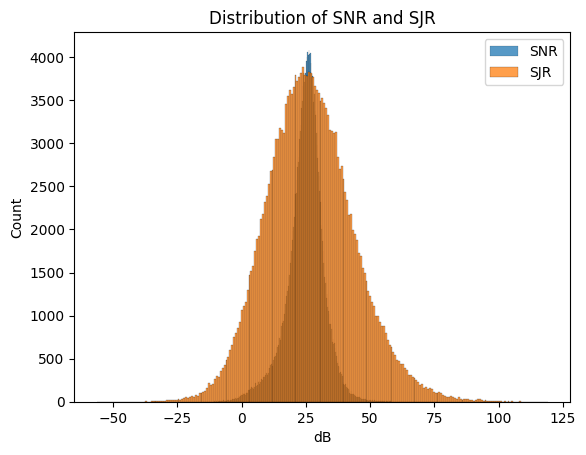

In [3]:
# analyze snr and sjr
def aggregate_over_sus(df, measure):
    all_vals = []
    for col in df.columns:
        if col.startswith(measure):
            vals = df[col].values
            vals = vals[np.isfinite(vals)]  # Filter out inf values of unjammed samples for SJR
            all_vals.extend(vals)

    return np.array(all_vals)

snr_values = aggregate_over_sus(labels, "snr")
print(f"Mean SNR: {np.mean(snr_values):.2f} dB, Std SNR: {np.std(snr_values):.2f} dB")
sjr_values = aggregate_over_sus(labels, "sjr")
print(f"Mean SJR: {np.mean(sjr_values):.2f} dB, Std SJR: {np.std(sjr_values):.2f} dB")

sns.histplot(snr_values, label="SNR")
sns.histplot(sjr_values, label="SJR")
plt.xlabel("dB")
plt.title("Distribution of SNR and SJR")
plt.legend()

In [4]:
def get_filename(sample_idx, su_idx):
    return f"{datapath}\\images\\spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png"

Text(0.5, 1.0, 'Sample 1201, SU 5, jammer: sweep,\nSNR: 35.70 dB, SJR: 30.73 dB')

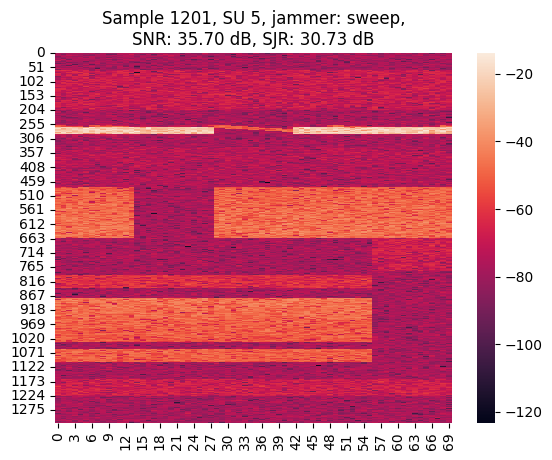

In [11]:
sample_idx = 1201
su_idx = 5

img = Image.open(get_filename(sample_idx, su_idx))
img = np.array(img)/255.0 * (max_val - min_val) + min_val

sns.heatmap(img)
plt.title(
    f"Sample {sample_idx}, SU {su_idx}, jammer: {labels[f'jammer_type'].values[sample_idx]},\n"
    f"SNR: {labels[f'snr_by_su_{su_idx}'].values[sample_idx]:.2f} dB, SJR: {labels[f'sjr_by_su_{su_idx}'].values[sample_idx]:.2f} dB"
)

<Axes: >

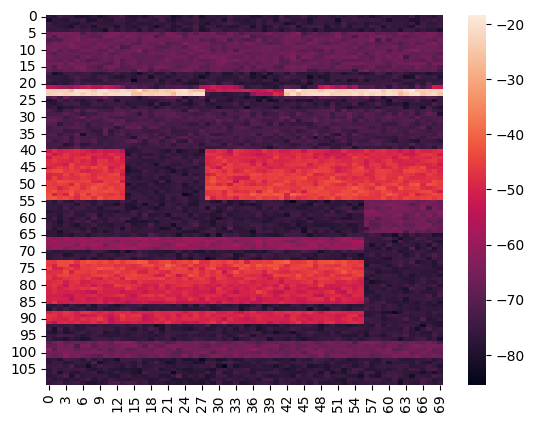

In [ ]:
# reduce resolution by aggregating subcarriers
num_sc_per_rb = 12
def aggregate_subcarriers(spectrogram, num_sc_per_rb):
    num_rows, num_cols = spectrogram.shape
    num_aggregated_rows = num_rows // num_sc_per_rb
    aggregated_spectrogram = np.zeros((num_aggregated_rows, num_cols))

    for i in range(num_aggregated_rows):
        start_row = i * num_sc_per_rb
        end_row = start_row + num_sc_per_rb
        aggregated_spectrogram[i, :] = 10*np.log10(np.sum(10**(spectrogram[start_row:end_row, :] / 10), axis=0))

    return aggregated_spectrogram

sns.heatmap(aggregate_subcarriers(img, num_sc_per_rb))